In [3]:
import numpy as np
import os
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, confusion_matrix
import json
from metrics_cls import evaluate_classification, plot_confusion_matrix, plot_roc_curve
from metrics_det import evaluate_detection

Tradition
Traditional-SVM - classification performance
Precision (macro): 0.2053
Recall (macro):    0.2264
F1 Score (macro):  0.2017
Accuracy:          0.2289
AUC (macro):       0.7129


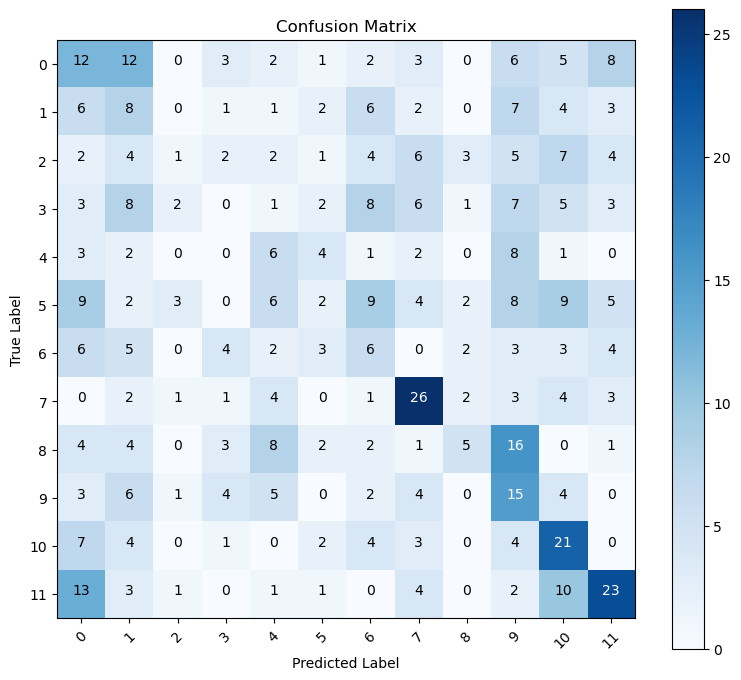

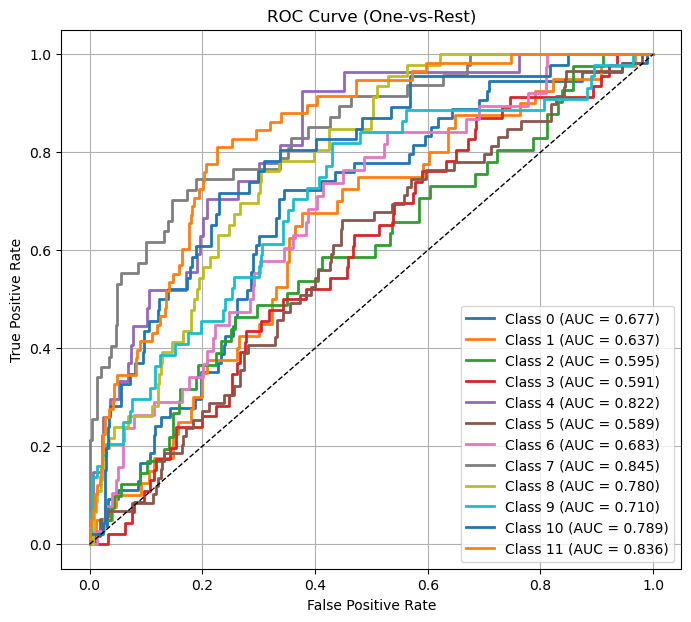

In [4]:
print("Tradition")
metrics_trad_cls, y_true, y_pred, y_probs = evaluate_classification(
    gt_label_dir='test/labels',
    pred_path='outputs/preds_test.json',
    output_json='results_trad_cls.json',
    method_name='Traditional-SVM',
    strategy='first'
)

plot_confusion_matrix(metrics_trad_cls["confusion_matrix"])

if y_probs is not None:
    plot_roc_curve(y_true, y_probs)


Yolo
YOLO - classification performance
Precision (macro): 0.9084
Recall (macro):    0.9011
F1 Score (macro):  0.9035
Accuracy:          0.9066
[mAP@0.50] = 0.6945
YOLO - detection performance
mAP@0.50            : 0.6945


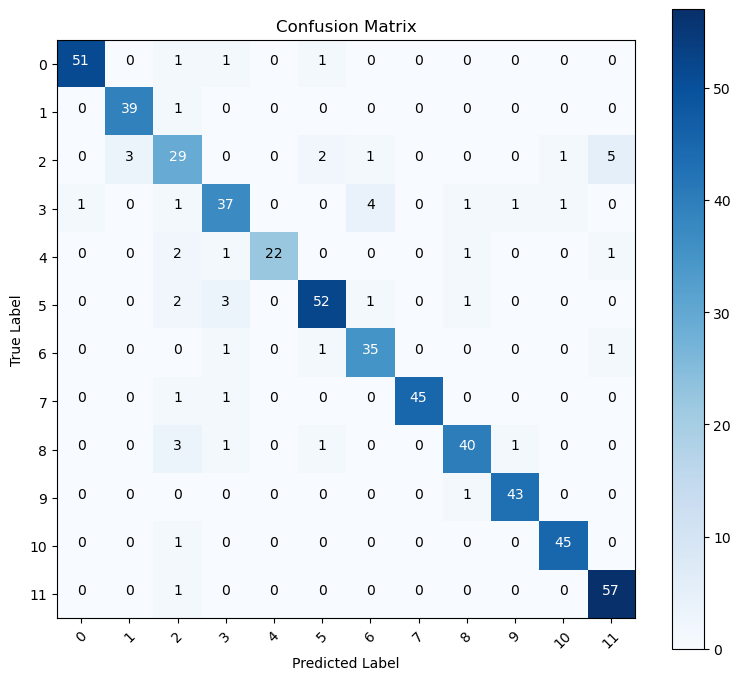

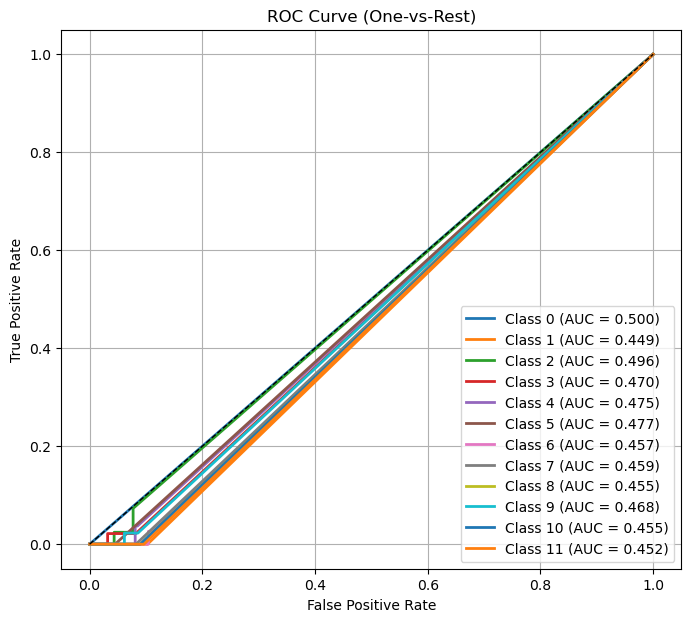

In [5]:
print("Yolo")
metrics_yolo_cls, y_true, y_pred, y_probs= evaluate_classification(
    gt_label_dir='test/labels',
    pred_path='outputs/pred_yolo_test_with_prob_onehot.json',
    output_json='results_yolo_cls.json',
    method_name='YOLO',
    strategy='first'
)

metrics_yolo_det = evaluate_detection(
    gt_label_dir='test/labels',
    pred_path='outputs/pred_yolo_test_with_prob_onehot.json',
    output_json='results_yolo_det.json',
    method_name='YOLO',
    num_classes=12,
    iou_thresholds=[0.5]
)
plot_confusion_matrix(metrics_yolo_cls["confusion_matrix"])

if y_probs is not None:
    plot_roc_curve(y_true, y_probs)

Frcnn
Faster-RCNN - classification performance
Precision (macro): 0.9063
Recall (macro):    0.9029
F1 Score (macro):  0.9017
Accuracy:          0.9066
[mAP@0.50] = 0.1315
Faster-RCNN - detection performance
mAP@0.50            : 0.1315


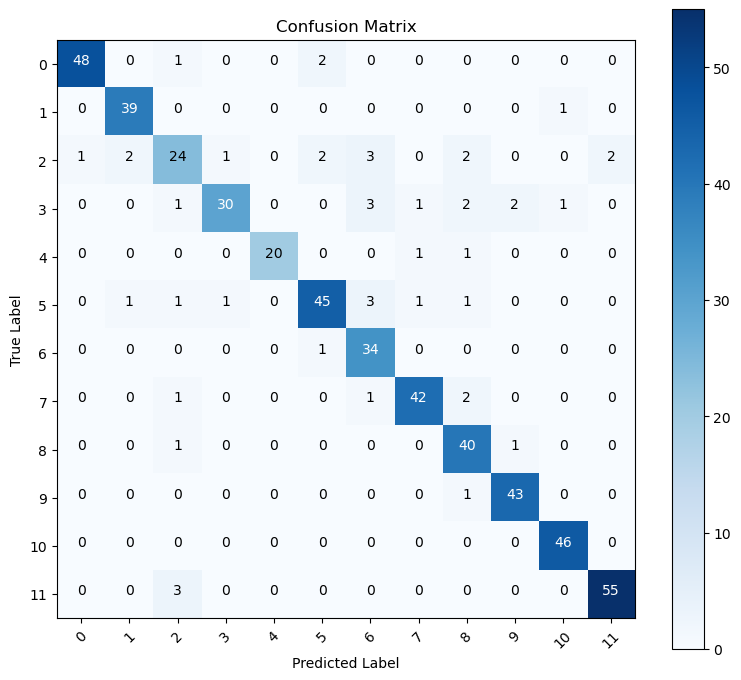

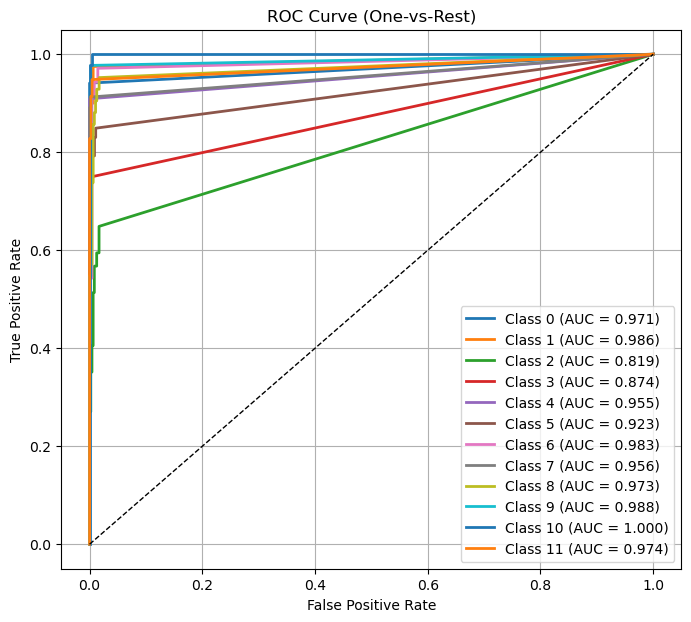

In [6]:
print("Frcnn")

metrics_frcnn_cls, y_true, y_pred, y_probs = evaluate_classification(
    gt_label_dir='test/labels',
    pred_path='outputs/pred_frcnn_test_with_prob_onehot.json',
    output_json='results_frcnn_cls.json',
    method_name='Faster-RCNN',
    strategy='first'
)

metrics_frcnn_det = evaluate_detection(
    gt_label_dir='test/labels',
    pred_path='outputs/pred_frcnn_test_with_prob_onehot.json',
    output_json='results_frcnn_det.json',
    method_name='Faster-RCNN',
    num_classes=12,
    iou_thresholds=[0.5]
)
plot_confusion_matrix(metrics_frcnn_cls["confusion_matrix"])

if y_probs is not None:
    plot_roc_curve(y_true, y_probs)

In [7]:
print("\n" + "="*70)
print("Traditional vs YOLO vs Frcnn")
print("="*70)
print(f"Traditional - Accuracy: {metrics_trad_cls['accuracy']:.2%}, F1: {metrics_trad_cls['f1']:.4f}")
print(f"YOLO        - Accuracy: {metrics_yolo_cls['accuracy']:.2%}, F1: {metrics_yolo_cls['f1']:.4f}, mAP@0.50: {metrics_yolo_det['mAP@0.50']:.4f}")
print(f"Faster-RCNN - Accuracy: {metrics_frcnn_cls['accuracy']:.2%}, F1: {metrics_frcnn_cls['f1']:.4f}, mAP@0.50: {metrics_frcnn_det['mAP@0.50']:.4f}")
print("="*70)


Traditional vs YOLO vs Frcnn
Traditional - Accuracy: 22.89%, F1: 0.2017
YOLO        - Accuracy: 90.66%, F1: 0.9035, mAP@0.50: 0.6945
Faster-RCNN - Accuracy: 90.66%, F1: 0.9017, mAP@0.50: 0.1315
